In [1]:
# Import and load computed data

import pandas as pd
import yaml
import sys
import matplotlib.pyplot as plt
import seaborn as sns 
import networkx as nx
import numpy as np



app_name = "deepspeedhigh"
cp_dir = "/p/lustre2/pandey2/cp_dir/deepspeed"

with open(f'/g/g91/pandey2/.dftracer/configuration.yaml', 'r') as file:
    dlp_yaml = yaml.safe_load(file)
    app_root = dlp_yaml["app"]
sys.path.insert(0, app_root)

import dfanalyzer
print(dfanalyzer.__file__)
from dfanalyzer.main import DFAnalyzer,get_dft_configuration,update_dft_configuration,setup_logging,setup_dask_cluster, reset_dask_cluster, get_dft_configuration
from dfanalyzer.graph_visualization.cytoscape import GraphFunctions, CytoGraph
from dfanalyzer.graph import DFGrepInterference, DFGrepWorkflow 
from dfanalyzer.plots import GrepIOPlots

events_obj = DFGrepInterference(app_name=app_name,  cp_dir = cp_dir, existing=True)
size_bins = [
0, 512, 1024, 2048, 4096, 8192, 16384, 32768, 65536, 131072, 262144, 524288,
1048576, 2097152, 4194304, 8388608, 16777216, 33554432, 67108864, 134217728,
268435456, 536870912, 1073741824, float('inf')
]
size_labels = [
'<512B', '512B-1KB', '1-2KB', '2-4KB', '4-8KB', '8-16KB', '16-32KB', '32-64KB',
'64-128KB', '128-256KB', '256-512KB', '512KB-1MB', '1-2MB', '2-4MB', '4-8MB',
'8-16MB', '16-32MB', '32-64MB', '64-128MB', '128-256MB', '256-512MB', '512MB-1GB', '>1GB'
]

degree_bins = [0,2,4,8,16,32,64,float('inf')]
degree_labels = ['<2','2-4','4-8','8-16', '16-32', '32-64','>64']


inter = events_obj.inter.compute()
inter_metadata = events_obj.inter_metadata.compute()
inter['IF_val'] = pd.cut(inter['interference'],
                 bins=[0, 0.1, 0.25, 0.5, 0.75, 1, float('inf')],
                 labels=[5, 4, 3, 2, 1, 0])
inter_metadata['IF_val'] = pd.cut(inter_metadata['interference'],
                 bins=[0, 0.1, 0.25, 0.5, 0.75, 1, float('inf')],
                 labels=[5, 4, 3, 2, 1, 0])
plot = GrepIOPlots()


/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/__init__.py


In [3]:
import csv

In [4]:
inter.to_csv("intefrerence.csv")

KeyboardInterrupt: 

In [2]:
events_obj.inter_metadata.mount_point.unique().compute()

0    /p/lustre2
1              
2        /l/ssd
Name: mount_point, dtype: string

In [3]:
def hmap(mp=None, df=None, size_bins=[], size_labels=[], degree_bins=[], degree_labels = []):
    # df= inter.compute()
    if mp:
        df= df[df['mount_point']==mp]
    else:
        mp = "All Mount Points"
    # size_bins, size_labels, degree_bins, degree_labels = binned_category()
    df['size_category'] = pd.cut(df['size'], bins=size_bins, labels=size_labels, right=False)
    df['deg_category'] = pd.cut(df['deg_caller'], bins=degree_bins, labels=degree_labels, right=False)
    df['IF_val'] = df['IF_val'].astype(float)
    all_combinations = pd.MultiIndex.from_product([df['size_category'].unique(), df['deg_category'].unique()], names=['size_category', 'deg_category'])
    merged = pd.merge(df, pd.DataFrame(index=all_combinations).reset_index(), on=['size_category', 'deg_category'], how='left')
    grouped = merged.groupby(['size_category', 'deg_category']).agg({'IF_val': 'mean'}).reset_index()
    pivot_table = grouped.pivot(index='size_category', columns='deg_category', values='IF_val').fillna(-1)
    # Create heatmap using seaborn
    plt.figure(figsize=(6, 6))
    sns.heatmap(pivot_table, annot=False, cmap='viridis', fmt='.1f', linewidths=.5, vmin=-1, vmax=5)
    plt.title(f'Average Interference Heatmap {mp}')
    plt.xlabel('Degrees')
    plt.ylabel('Sizes')
    plt.show()

def hmap_metadata(mp=None, df=None, size_bins=[], size_labels=[], degree_bins=[], degree_labels = []):
    # df= inter.compute()
    if mp:
        df= df[df['mount_point']==mp]
    else:
        mp = "All Mount Points"
    # size_bins, size_labels, degree_bins, degree_labels = binned_category()
    # df['size_category'] = pd.cut(df['size'], bins=size_bins, labels=size_labels, right=False)
    df['deg_category'] = pd.cut(df['deg_caller'], bins=degree_bins, labels=degree_labels, right=False)
    df['IF_val'] = df['IF_val'].astype(float)
    all_combinations = pd.MultiIndex.from_product([df['name'].unique(), df['deg_category'].unique()], names=['name', 'deg_category'])
    merged = pd.merge(df, pd.DataFrame(index=all_combinations).reset_index(), on=['name', 'deg_category'], how='left')
    grouped = merged.groupby(['name', 'deg_category']).agg({'IF_val': 'mean'}).reset_index()
    pivot_table = grouped.pivot(index='name', columns='deg_category', values='IF_val').fillna(-1)
    # Create heatmap using seaborn
    plt.figure(figsize=(6, 6))
    sns.heatmap(pivot_table, annot=True, cmap='viridis', fmt='.1f', linewidths=.5, vmin=-1, vmax=5)
    plt.title(f'Average Interference Heatmap {mp}')
    plt.xlabel('Degrees')
    plt.ylabel('Sizes')
    plt.show()


def plot_avg_degx(inter):
    # 1. Group by `trange` and compute the average deg_caller for the entire DataFrame
    overall_avg = inter.groupby('trange')['deg_caller'].mean().reset_index()

    # 2. Filter for `name == "read"` and compute the average deg_caller by `trange`
    read_avg = inter[inter['name'] == 'read'].groupby('trange')['deg_caller'].mean().reset_index()

    # 3. Filter for `name == "write"` and compute the average deg_caller by `trange`
    write_avg = inter[inter['name'] == 'write'].groupby('trange')['deg_caller'].mean().reset_index()

    # Plotting
    plt.figure(figsize=(10, 6))

    # Plot the overall average deg_caller
    plt.plot(overall_avg['trange'], overall_avg['deg_caller'], label='Overall Avg',linestyle = '--')

    # Plot the read average deg_caller
    plt.plot(read_avg['trange'], read_avg['deg_caller'], label='Read Avg',linestyle = '--')

    # Plot the write average deg_caller
    plt.plot(write_avg['trange'], write_avg['deg_caller'], label='Write Avg', linestyle = '--')
    # Customize plot to show the actual range of trange
    # inter['trange'].max()
    plt.xlim(0, inter['trange'].max())  # Set x-axis limits to the min and max of trange
    plt.xlabel('trange')
    plt.ylabel('Average Degree')
    plt.title('Average Degree by trange')
    plt.legend()
    # Show the plot
    plt.tight_layout()
    plt.show()

def plot_avg_deg(inter,inter_metadata):
    # 1. Group by `trange` and compute the average deg_caller for the entire DataFrame
    overall_avg = inter.groupby('trange')['deg_caller'].mean().reset_index()

    overall_metadata = inter_metadata.groupby('trange')['deg_caller'].mean().reset_index()
    # # 2. Filter for `name == "read"` and compute the average deg_caller by `trange`
    # read_avg = inter[inter['name'] == 'read'].groupby('trange')['deg_caller'].mean().reset_index()

    # # 3. Filter for `name == "write"` and compute the average deg_caller by `trange`
    # write_avg = inter[inter['name'] == 'write'].groupby('trange')['deg_caller'].mean().reset_index()

    # Plotting
    plt.figure(figsize=(10, 6))

    # Plot the overall average deg_caller
    plt.plot(overall_avg['trange'], overall_avg['deg_caller'], label='Data',linestyle = '--')

    # Plot the read average deg_caller
    plt.plot(overall_metadata['trange'], overall_metadata['deg_caller'], label='Metadata',linestyle = '--')

    # Customize plot to show the actual range of trange
    # inter['trange'].max()
    plt.xlim(0, inter['trange'].max())  # Set x-axis limits to the min and max of trange
    # Set x-ticks at intervals of 30 seconds
    xticks = np.arange(0, inter['trange'].max() + 1, 30)
    plt.xticks(xticks, [f'{int(x/30)}*30 sec' for x in xticks])
    plt.xlabel('trange')
    plt.ylabel('Average Degree')
    plt.title('Average Degree by trange')
    plt.legend()
    # Show the plot
    plt.tight_layout()
    plt.show()

def scatter_deg_bc(betweenness_centrality, degree, filtered_nodes, pid):
    # 2. Get unique communities from the pid map for filtered nodes
    communities = set(pid[node] for node in filtered_nodes)
    # print(communities)
    
    # 3. Assign a unique color to each community
    color_map = {community: np.random.rand(3,) for community in communities}  # Random color for each community

    # 4. Plot the scatter plot with color-coded communities for filtered nodes
    plt.figure(figsize=(4, 4))

    for community in communities:
        # Filter nodes that belong to this community and start with 'p_'
        community_nodes = [node for node in filtered_nodes if pid[node] == community]
        
        # Get x (degree) and y (betweenness centrality) values for these nodes
        x = [degree[node] for node in community_nodes]
        y = [betweenness_centrality[node] for node in community_nodes]
        # Adding jitter
        jitter = 0.002
        x = [xi + np.random.uniform(-jitter, jitter) for xi in x]
        y = [yi + np.random.uniform(-jitter, jitter) for yi in y]
        # Plot this community's nodes
        plt.scatter(x, y, c=[color_map[community]], s=100, alpha=0.7, label=community)

    # 5. Set x-axis ticks to integers
    plt.xticks(np.arange(min(degree.values()), max(degree.values())+1, 1))

    # Add labels, title, and legend
    plt.xlabel('Degree')
    plt.ylabel('Betweenness Centrality')
    plt.title('Betweenness Centrality vs Degree')
    plt.grid(True)

    # Add legend (community names)
    plt.legend(title='Category', loc='best')

    # Show the plot
    plt.tight_layout()
    plt.show()

def scatter_deg_bc_finer(betweenness_centrality, degree, filtered_nodes, pid):
    # 2. Get unique communities from the pid map for filtered nodes
    communities = set(pid[node] for node in filtered_nodes)
    # print(communities)
    
    # 3. Assign a unique color to each community
    color_map = {community: np.random.rand(3,) for community in communities}  # Random color for each community

    # 4. Plot the scatter plot with color-coded communities for filtered nodes
    plt.figure(figsize=(4, 4))

    for community in communities:
        # Filter nodes that belong to this community and start with 'p_'
        community_nodes = [node for node in filtered_nodes if pid[node] == community]
        
        # Get x (degree) and y (betweenness centrality) values for these nodes
        x = [degree[node] for node in community_nodes]
        y = [betweenness_centrality[node] for node in community_nodes]
        # Adding jitter
        jitter = 0.002
        x = [xi + np.random.uniform(-jitter, jitter) for xi in x]
        y = [yi + np.random.uniform(-jitter, jitter) for yi in y]
        # Plot this community's nodes
        plt.scatter(x, y, c=[color_map[community]], s=100, alpha=0.7, label=community)

    # 5. Set x-axis ticks to integers
    # plt.xticks(np.arange(min(degree.values()), max(degree.values())+1, 50))
    plt.xticks(np.arange(0, max(degree.values())+1, 50))
    # Add labels, title, and legend
    plt.xlabel('Degree')
    plt.ylabel('Betweenness Centrality')
    plt.title('Betweenness Centrality vs Degree')
    plt.grid(True)

    # Add legend (community names)
    plt.legend(title='Category', loc='best')

    # Show the plot
    plt.tight_layout()
    plt.show()






# Relationship 1 (Events that interfer with each Other)

- **Question**: Can we identify I/O events which suffer from most I/O interferences?

- **Technique**: To do so, we calculate Interference Factor; which is the cost of I/O event by cost of an isolated I/O event. Then, we use this metric to identify the ideal parallelism fo a storage target by observing the Interferance factor per transfer size.

- **Graph**: (Overlap Graph)
    - *Vertex*: I/O events
    - *Edges*: Time overlap between the requests
    - *Graph Type*: Undirected
    - *Metric*: Interference Factor 

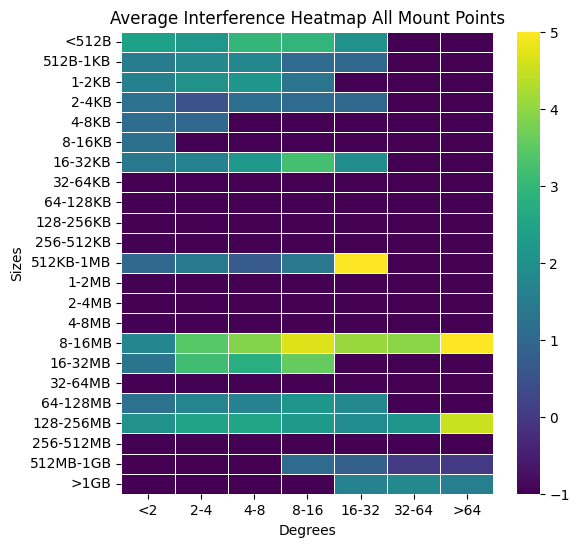

In [4]:
hmap(df=inter, size_bins=size_bins,
          size_labels=size_labels, degree_bins=degree_bins, degree_labels=degree_labels)

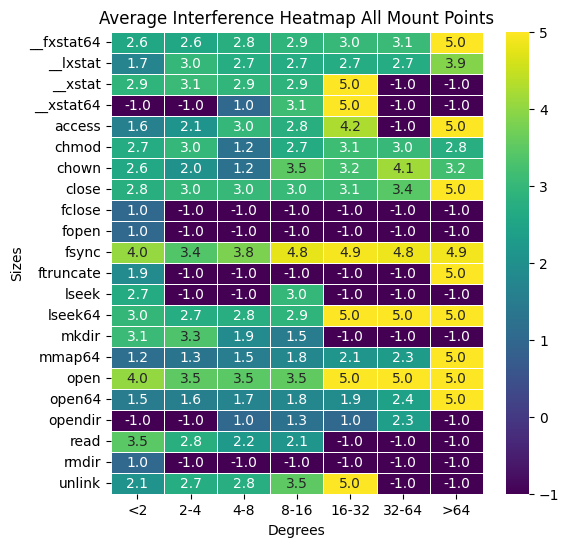

In [5]:
hmap_metadata(df=inter_metadata, size_bins=size_bins,
          size_labels=size_labels, degree_bins=degree_bins, degree_labels=degree_labels)

## 1.1 Relationship within storage targets (Dimensions)
- Storage Target 
- Operations

In [6]:
read_df = inter.query('name == "read"')
write_df = inter.query('name == "write"')

In [7]:
inter.mount_point.unique()

<ArrowStringArray>
['/p/lustre2', '/l/ssd', '']
Length: 3, dtype: string

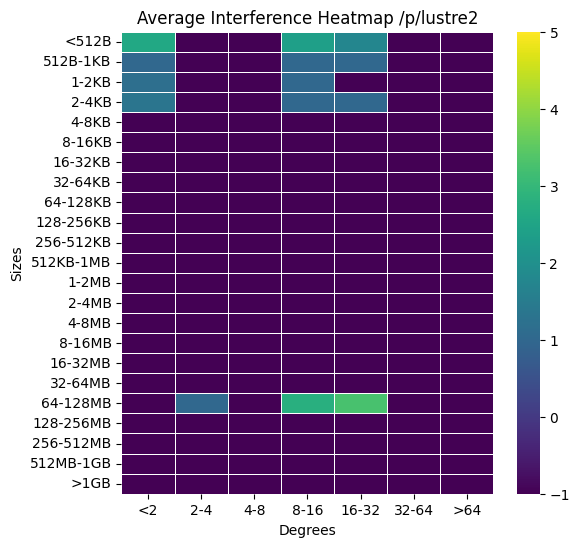

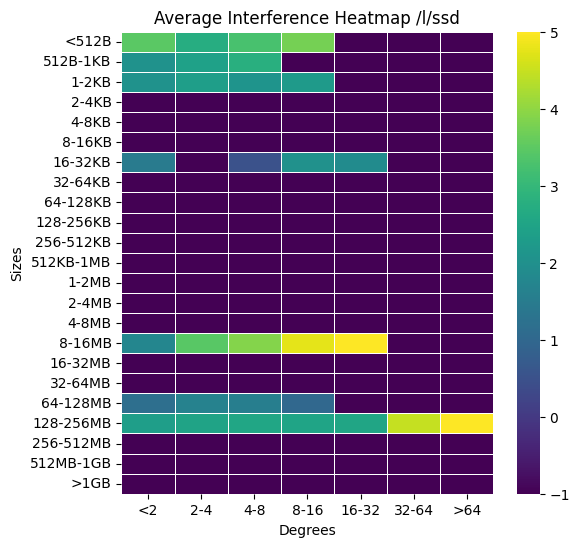

In [8]:
hmap(mp='/p/lustre2',df=read_df, size_bins=size_bins,
          size_labels=size_labels, degree_bins=degree_bins, degree_labels=degree_labels)
hmap(mp='/l/ssd',df=read_df, size_bins=size_bins,
          size_labels=size_labels, degree_bins=degree_bins, degree_labels=degree_labels)

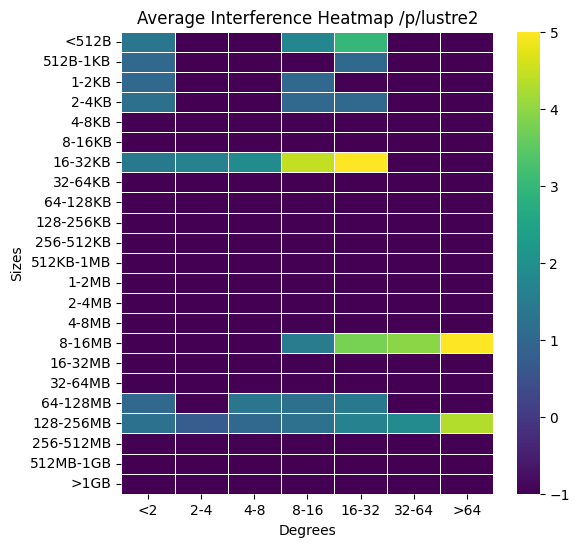

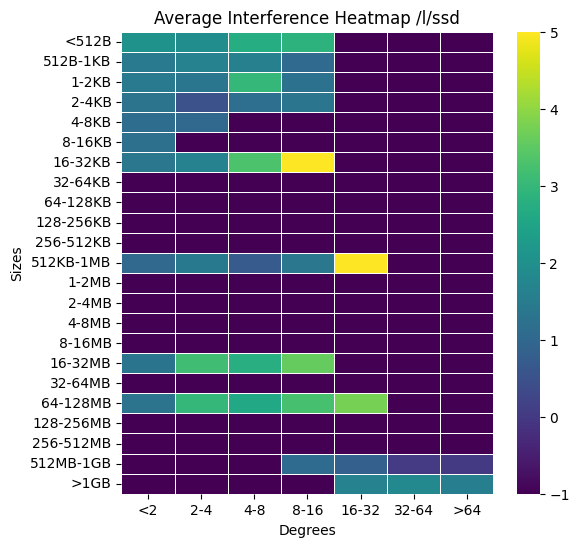

In [9]:
hmap(mp='/p/lustre2',df=write_df, size_bins=size_bins,
          size_labels=size_labels, degree_bins=degree_bins, degree_labels=degree_labels)
hmap(mp='/l/ssd',df=write_df, size_bins=size_bins,
          size_labels=size_labels, degree_bins=degree_bins, degree_labels=degree_labels)


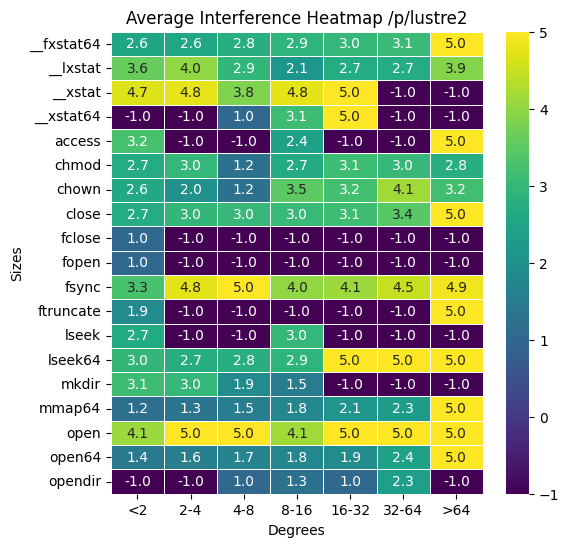

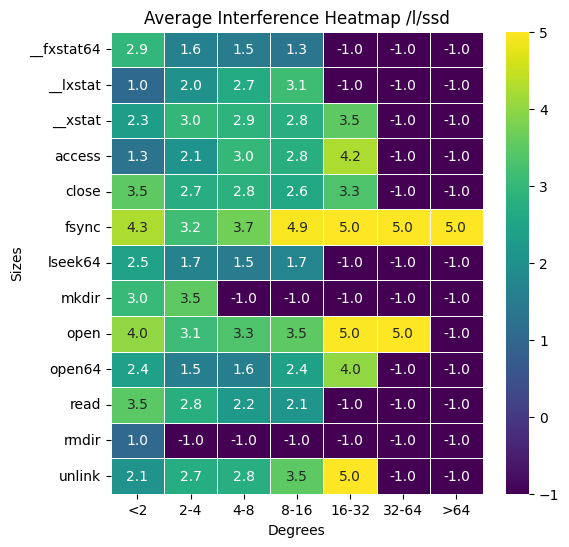

In [10]:
hmap_metadata(mp='/p/lustre2',df=inter_metadata, size_bins=size_bins,
          size_labels=size_labels, degree_bins=degree_bins, degree_labels=degree_labels)
hmap_metadata(mp='/l/ssd',df=inter_metadata, size_bins=size_bins,
          size_labels=size_labels, degree_bins=degree_bins, degree_labels=degree_labels)


## 1.2 Relationship across type of operation

# Relationship 2 (Events that contribute towards I/O Phase)

- **Question**: Can we identify the phases within the workloads which are more data intensive than others?

- **Technique**: To do so, we patition the the graph into different ranges of time and compute the average overlap count during that range. Higher overlap on I/0 request suggest I/O bursts during that range.

- **Graph**: (Overlap Graph)
    - *Vertex*: I/O events
    - *Edges*: Time overlap between the requests
    - *Graph Type*: Undirected
    - *Metric*: Average Degree 

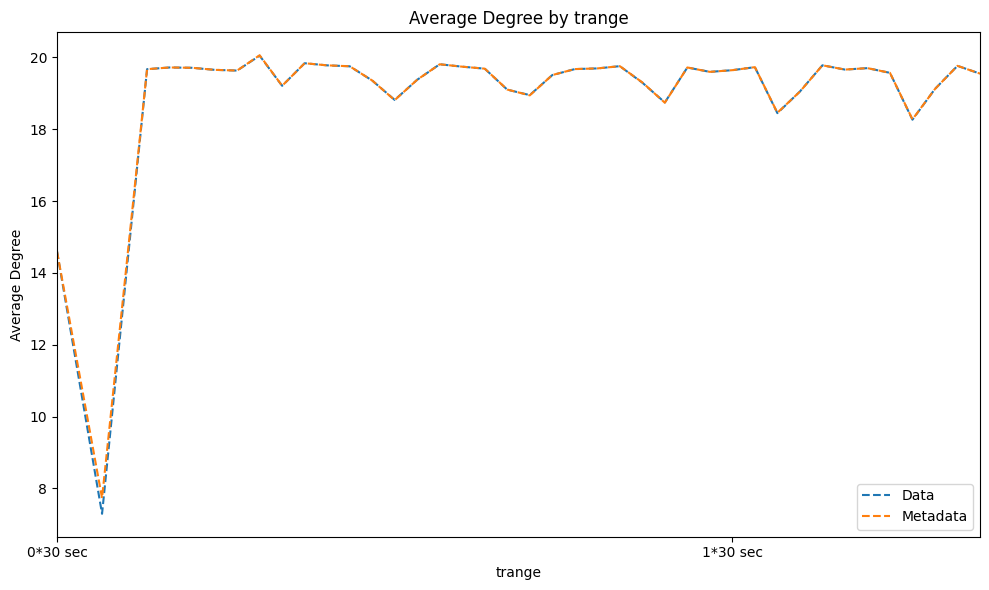

In [11]:
plot_avg_deg(inter,inter_metadata)

## 2.1 Relationship across storage targets

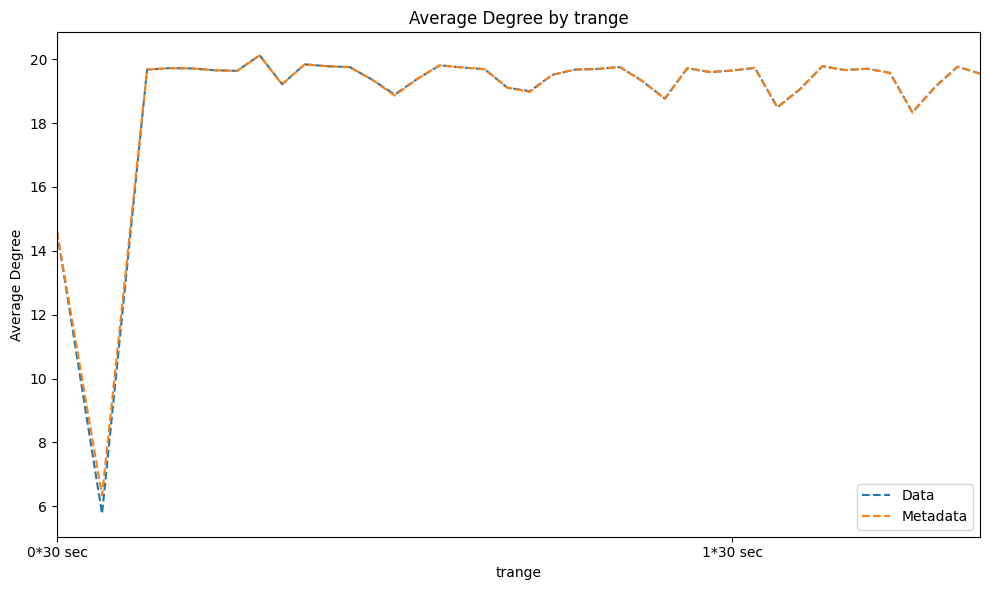

In [12]:
a = inter.query(' mount_point == "/p/lustre2"')
m = inter_metadata.query( 'mount_point == "/p/lustre2"')
# plot_avg_deg(inter,inter_metadata)
plot_avg_deg(a,m)


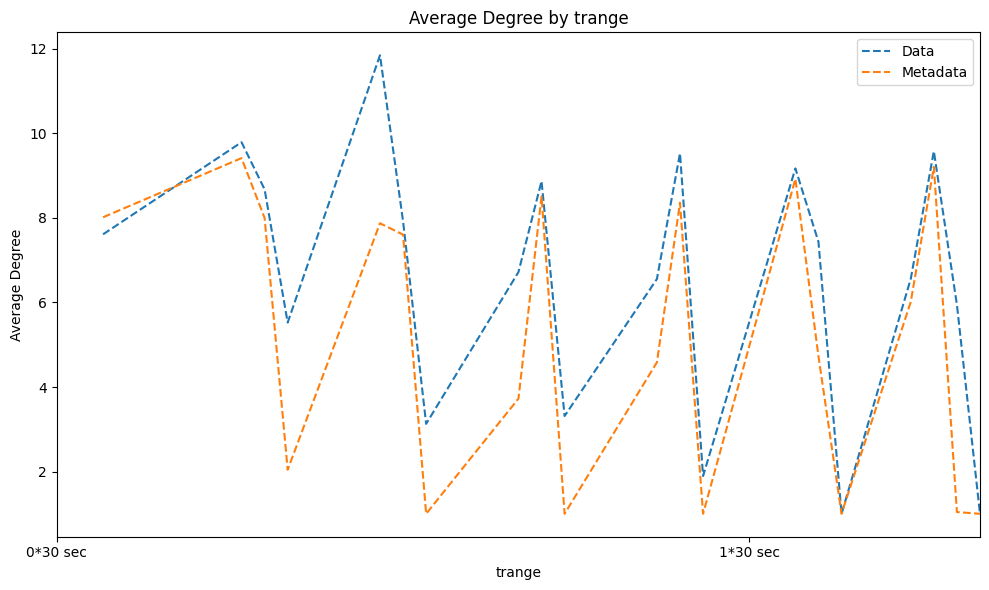

In [13]:
a = inter.query(' mount_point == "/l/ssd"')
m = inter_metadata.query( 'mount_point == "/l/ssd"')
# plot_avg_deg(inter,inter_metadata)
plot_avg_deg(a,m)

## 2.2 Relationship across compute target (hostname)

## 2.3 Relationship across types of operations

# Relationship 3 (Events that dictates the makespan of the workload)

- **Question**: Can we identify set of processes and files within the dataflow that dictates the makespan of the workload?

- **Technique**: To do so, we patition the the  
 To do so, we calculate Interference Factor; which is the cost of I/O event by cost of an isolated I/O event. Then, we use this metric to identify the ideal parallelism fo a storage target by observing the Interferance factor per transfer size.

- **Graph**: (Overlap Graph)
    - *Vertex*: Processes / Files
    - *Edges*: 
    - *Graph Type*: Directed
    - *Metric*: Betweeness Centrality, Degree Centrality 

relationshiop.
-   dimensions 
-   characterization 
sentence what characterization is trying to find?

## 3.1 Important App

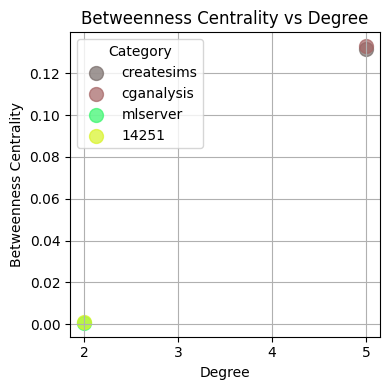

In [31]:
# DO NOT DELETE
graph_df = pd.read_csv("/p/lustre2/pandey2/cp_centrality/mummi/graph_app.csv")
G = nx.from_pandas_edgelist(graph_df, source='src', target='dest', create_using=nx.DiGraph())

pid_map = {i:i[2:] for i in G.nodes()}
communities = G.nodes() #

communities = pid_map.values() 
filtered_p = [node for node in G.nodes() if str(node).startswith('p_')]
filtered_f = [node for node in G.nodes() if str(node).startswith('f_')]
betweenness_centrality = nx.betweenness_centrality(G)
degree_p = dict(G.degree(filtered_p))  # Only for filtered nodes
degree_f = dict(G.degree(filtered_f))  # Only for filtered nodes
scatter_deg_bc(betweenness_centrality, degree_p, filtered_p, pid_map)
# scatter_deg_bc(betweenness_centrality, degree_f, filtered_f, pid_map)

## 3.2 Important Processes

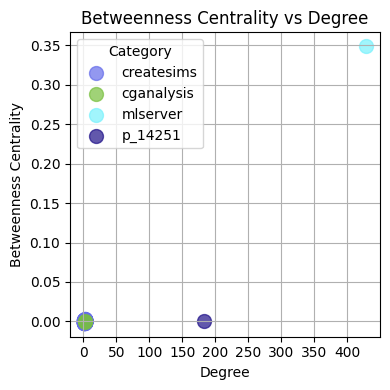

In [34]:
wf_obj = DFGrepWorkflow()
wf_obj.trace_path = "/usr/workspace/iopp/graph-io/dlp_logs/mummi-32-node/*pfw.gz"
pid_map = wf_obj.get_pid_map()
updated_dict = {
    f'f_{key}' if key.startswith('/') else f'p_{key}': value
    for key, value in pid_map.items()
}
for node in G.nodes():
    if node not in updated_dict.keys():
        updated_dict[node] = node
        
graph_df = pd.read_csv("/p/lustre2/pandey2/cp_centrality/mummi/graph_finer.csv")
G = nx.from_pandas_edgelist(graph_df, source='src', target='dest', create_using=nx.DiGraph())

# communities = pid_map.values() 
filtered_p = [node for node in G.nodes() if str(node).startswith('p_')]
filtered_f = [node for node in G.nodes() if str(node).startswith('/')]
betweenness_centrality = nx.betweenness_centrality(G)
degree_p = dict(G.degree(filtered_p))  # Only for filtered nodes
degree_f = dict(G.degree(filtered_f))  # Only for filtered nodes
scatter_deg_bc_finer(betweenness_centrality, degree_p, filtered_p, updated_dict)
# scatter_deg_bc_finer(betweenness_centrality, degree_f, filtered_f, updated_dict)


In [36]:
values = list(pid_map.values())

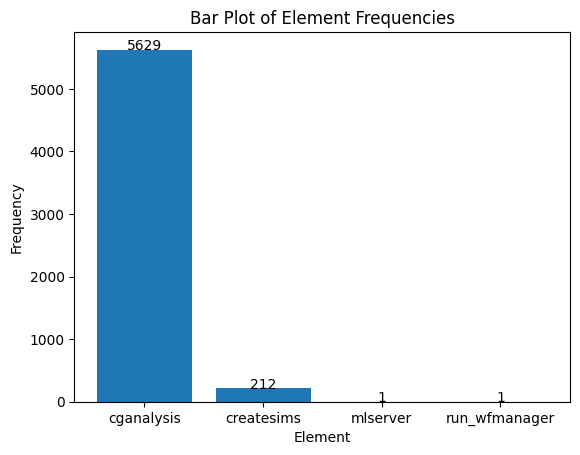

In [39]:
from collections import Counter
# Count occurrences of each unique element
counter = Counter(values)

# Extract the elements (keys) and their counts (values)
elements = list(counter.keys())
counts = list(counter.values())

# Create the bar plot
plt.bar(elements, counts)

# Add labels and title
plt.xlabel('Element')
plt.ylabel('Frequency')
plt.title('Bar Plot of Element Frequencies')

# Add counts on top of each bar
for i in range(len(elements)):
    plt.text(elements[i], counts[i] + 0.1, str(counts[i]), ha='center')

# Display the plot
plt.show()

When comparing the betweenness centrality values of these two views (app and processes), in the abstract graph, *cganalysis* and *createsims* are seen as critical applications controlling the flow of information. However, in the fine-grained view, where all the PIDs associated with the applications are considered, the PID associated with ML server is observed as the key component directly interacting with multiple files and significantly contributing to the control of information flow across the workflow.

## 3.3 Important Files

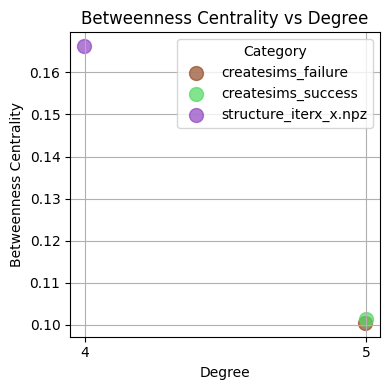

In [32]:
scatter_deg_bc(betweenness_centrality, degree_f, filtered_f, pid_map)

## 3.3 Important Dir

In [ ]:
## 3.2 Relationship across storage targets